In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [4]:
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/classification problems/Social_Network_Ads.csv")
df = pd.DataFrame(data)
df['ones'] = 1

In [8]:
df.head(5)

,Age,EstimatedSalary,Purchased,ones
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,1
3,27,57000,0,1
4,19,76000,0,1


[[-0.6743817]
 [ 1.0218453]]


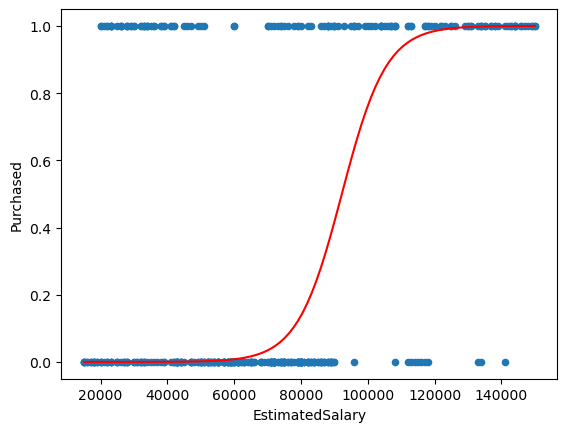

[9.30435218e-06 1.14166046e-05 1.40083690e-05 1.71884980e-05
 2.10905532e-05 2.58784124e-05 3.17531500e-05 3.89614779e-05
 4.78061003e-05 5.86584175e-05 7.19741089e-05 8.83122475e-05
 1.08358745e-04 1.32955106e-04 1.63133687e-04 2.00160928e-04
 2.45590356e-04 3.01327545e-04 3.69709714e-04 4.53603242e-04
 5.56523064e-04 6.82778816e-04 8.37653608e-04 1.02762254e-03
 1.26061959e-03 1.54636325e-03 1.89675319e-03 2.32635288e-03
 2.85297540e-03 3.49839279e-03 4.28919237e-03 5.25780627e-03
 6.44374344e-03 7.89505446e-03 9.67005985e-03 1.18393685e-02
 1.44882041e-02 1.77190401e-02 2.16545143e-02 2.64405459e-02
 3.22495069e-02 3.92831949e-02 4.77752132e-02 5.79921753e-02
 7.02329301e-02 8.48247576e-02 1.02115269e-01 1.22458640e-01
 1.46194928e-01 1.73621771e-01 2.04958844e-01 2.40307207e-01
 2.79607914e-01 3.22606588e-01 3.68832203e-01 4.17598104e-01
 4.68030530e-01 5.19124694e-01 5.69821963e-01 6.19096121e-01
 6.66034143e-01 7.09898442e-01 7.50162575e-01 7.86518864e-01
 8.18862077e-01 8.472567

In [18]:
X = df[['ones','EstimatedSalary']].to_numpy()
y = df[['Purchased']].to_numpy()

# Normalize ONLY salary
mu = X[:,1].mean()
sigma = X[:,1].std()
X[:,1] = (X[:,1] - mu) / sigma

teta = np.array([[0.0],[0.0]])
m = len(X)
alpha = 0.01
epoch = 100000

for i in range(epoch):
    z = X @ teta
    ypred = 1/(1 + np.exp(-z))
    error = ypred - y
    grad = (1/m) * (X.T @ error)
    teta = teta - alpha * grad

print(teta)

# Convert back to original scale
worig = teta[1] / sigma
borig = teta[0] - (teta[1] * mu / sigma)

# Plot
ax = df.plot.scatter(x='EstimatedSalary', y='Purchased')

x_vals = np.linspace(df['EstimatedSalary'].min(), df['EstimatedSalary'].max(), 100)
z = worig * x_vals + borig
y_vals = 1/(1 + np.exp(-z*5))

ax.plot(x_vals, y_vals, color='red')
plt.show()
print(y_vals)

the value of teta predicted are: [[-0.84423385]
 [ 0.965447  ]
 [ 2.45174596]]
the amount of iteration : 99999


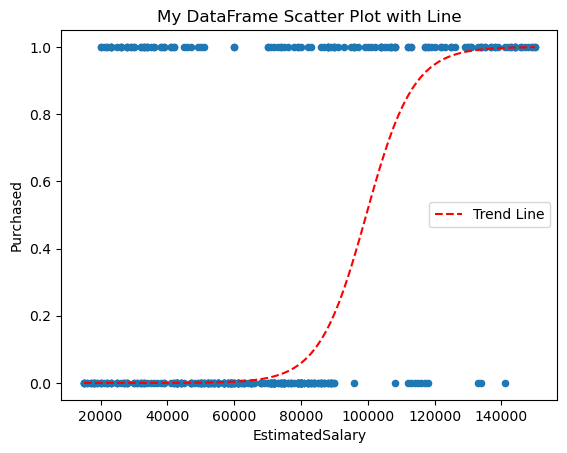

[6.26217394e-06 7.59752830e-06 9.21763277e-06 1.11832061e-05
 1.35679137e-05 1.64611281e-05 1.99712777e-05 2.42299088e-05
 2.93966144e-05 3.56650118e-05 4.32699954e-05 5.24965328e-05
 6.36903359e-05 7.72708021e-05 9.37467118e-05 1.13735264e-04
 1.37985162e-04 1.67404600e-04 2.03095203e-04 2.46393154e-04
 2.98919053e-04 3.62638321e-04 4.39934369e-04 5.33697208e-04
 6.47430698e-04 7.85382306e-04 9.52699997e-04 1.15562179e-03
 1.40170458e-03 1.70010005e-03 2.06188691e-03 2.50047036e-03
 3.03206134e-03 3.67625013e-03 4.45669083e-03 5.40191502e-03
 6.54629455e-03 7.93117423e-03 9.60619465e-03 1.16308228e-02
 1.40761025e-02 1.70266246e-02 2.05827006e-02 2.48626913e-02
 3.00054027e-02 3.61723966e-02 4.35499823e-02 5.23505442e-02
 6.28127264e-02 7.51998434e-02 8.97957308e-02 1.06897139e-01
 1.26801747e-01 1.49791040e-01 1.76107713e-01 2.05928075e-01
 2.39331109e-01 2.76267295e-01 3.16531811e-01 3.59747678e-01
 4.05364354e-01 4.52675668e-01 5.00857813e-01 5.49024032e-01
 5.96288734e-01 6.418314

In [45]:
X = df[['ones','EstimatedSalary','Age']].to_numpy()
y = df[['Purchased']].to_numpy()

mu = X[:,1].mean()
sigma = X[:,1].std()
X[:,1] = (X[:,1] - mu) / sigma

mu1 = X[:,2].mean()
sigma1 = X[:,2].std()
X[:,2] = (X[:,2] - mu1) / sigma1

teta = np.array([[0.0],[0.0],[0.0]])
m = len(X)
alpha = 0.01 
epoch = 100000


for i in range(epoch):
    z = X @ teta
    ypred = 1/(1+(np.exp(-z)))
    error = ypred - y
    grad = (1/m)* (X.T @ error)
    
    teta = teta - (alpha * grad)
print(f"the value of teta predicted are: {teta}")
print(f"the amount of iteration : {i}")
"""
worig = teta[1] * (y.std()/x[1].std())
borig = y.mean() - (worig * x[1].mean())
"""

worig1 = teta[2] / sigma1
worig = teta[1] / sigma
borig = teta[0] - (teta[1] * mu / sigma)

ax = df.plot.scatter(x = 'EstimatedSalary' , y ='Purchased')


x_vals = np.linspace(df['EstimatedSalary'].min(), df['EstimatedSalary'].max(), 100)
z = (x_vals * worig) + borig
yvalues = 1/(1+(np.exp(-z*5)))

ax.plot(x_vals, yvalues, color='red', linestyle='--', label='Trend Line')

plt.title('My DataFrame Scatter Plot with Line')
plt.legend()
plt.show()

plt.show()

print(yvalues)



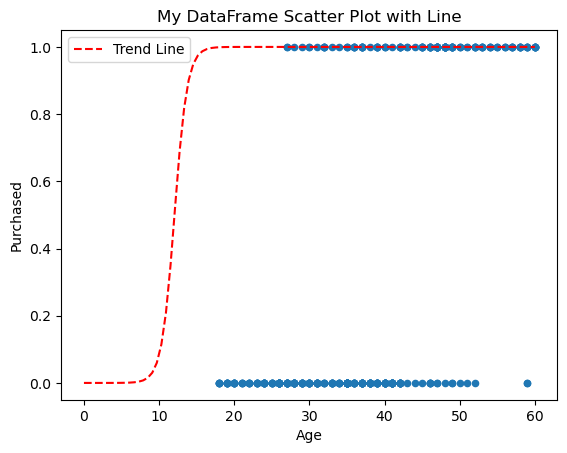

[7.46967914e-07 1.51874471e-06 3.08792870e-06 6.27840093e-06
 1.27652521e-05 2.59541514e-05 5.27689381e-05 1.07284713e-04
 2.18108642e-04 4.43361708e-04 9.01036634e-04 1.83029668e-03
 3.71436129e-03 7.52322058e-03 1.51783373e-02 3.03843121e-02
 5.98974291e-02 1.14686709e-01 2.08478773e-01 3.48758348e-01
 5.21266277e-01 6.88846999e-01 8.18222723e-01 9.01497058e-01
 9.49000250e-01 9.74249322e-01 9.87167063e-01 9.93646920e-01
 9.96865231e-01 9.98455760e-01 9.99239897e-01 9.99626012e-01
 9.99816026e-01 9.99909507e-01 9.99955491e-01 9.99978108e-01
 9.99989233e-01 9.99994704e-01 9.99997395e-01 9.99998719e-01
 9.99999370e-01 9.99999690e-01 9.99999848e-01 9.99999925e-01
 9.99999963e-01 9.99999982e-01 9.99999991e-01 9.99999996e-01
 9.99999998e-01 9.99999999e-01 9.99999999e-01 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.000000

In [49]:
ax = df.plot.scatter(x = 'Age' , y ='Purchased')


x_vals = np.linspace(0, df['Age'].max(), 100)
z = (x_vals * worig1) + borig
yvalues = 1/(1+(np.exp(-z*5)))

ax.plot(x_vals, yvalues, color='red', linestyle='--', label='Trend Line')

plt.title('My DataFrame Scatter Plot with Line')
plt.legend()
plt.show()

plt.show()

print(yvalues)